In [2]:
%matplotlib inline

PARTICLE_SHAPE = (3,)
RESPONSE_SHAPE = (105, 105)

import torch
import sys

sys.path.append('../../..')

from focal.utils.data import *

import numpy as np
from tqdm import tqdm

from pathlib import Path
from utilss.image_analyzis.energy_characteristics import get_image_from_characteristics

In [3]:
# data_dir = Path('/home/xsalonx/studia/inf.informaty-zlozonych-systemow/focal/data/single-shower-first/cleaned-1')
# approx_name = '3lapx101-3-16-512-2.8e-3'

data_dir = Path('/home/xsalonx/studia/inf.informaty-zlozonych-systemow/focal/data/single-shower-09062025/cleaned-2-energy-ratio_30000')
approx_name = '3lapx100-3-16-512-2.8e-3'

# data_dir = Path('/home/xsalonx/studia/inf.informaty-zlozonych-systemow/focal/data/many-showers/cleaned-1')
# approx_name = '13lapx110-3-16-512-2.8e-3'

# approx_name = 'apx20-3-16-512-2.8e-3'

In [4]:
responses_scaler = '1log+1'

data_scope = load_data_scope(
    data_dir=data_dir,
    train_batch_size=32,
    eval_batch_size=32,
    test_batch_size=32,
    samples_no=32,
    data_load_config=[
        ['particles', 'standard',  lambda p: p[:, None]],
        ['responses', responses_scaler, lambda p: p[:, None]],
        ['characteristics', responses_scaler],
        ['centroids', 'none'],
        [f'approx/{approx_name}/approx', 'none']
    ]
)

In [17]:
from lpips_j.lpips import LPIPS
import jax.numpy as jnp

def perceptual_loss_factory():
    lpips = LPIPS()
    x_sample = jnp.zeros((1, 105, 105, 1))
    params = lpips.init(jax.random.PRNGKey(0), x_sample, x_sample)

    def apply(x, y):
        # m = jnp.max(jnp.concat([x, y]))
        m = 16.1
        x = 2 * (x / m) - 1
        y = 2 * (y / m) - 1
        return lpips.apply(params, x, y).mean()

    return jax.jit(apply)

perceptual_loss = perceptual_loss_factory()

In [18]:
characterisitc_transform = data_scope['scalers'][2]
from utilss.plot import plot_responses_rows

train_responses = characterisitc_transform.transform(data_scope['dataslices']['train'][1][:20])
train_approxes = characterisitc_transform.transform(data_scope['dataslices']['train'][4][:, None][:20])

In [19]:
data_scope['dataslices']['train'][1].max()

np.float64(16.117673261764562)

In [20]:
perceptual_loss(train_responses.transpose(0, 2, 3, 1)[0:2],
                train_responses.transpose(0, 2, 3, 1)[1:2])

Array(0.18792455, dtype=float32)

(<Figure size 8200x800 with 80 Axes>,
 array([[<Axes: ylabel='Group 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Group 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >]], dtype=object))

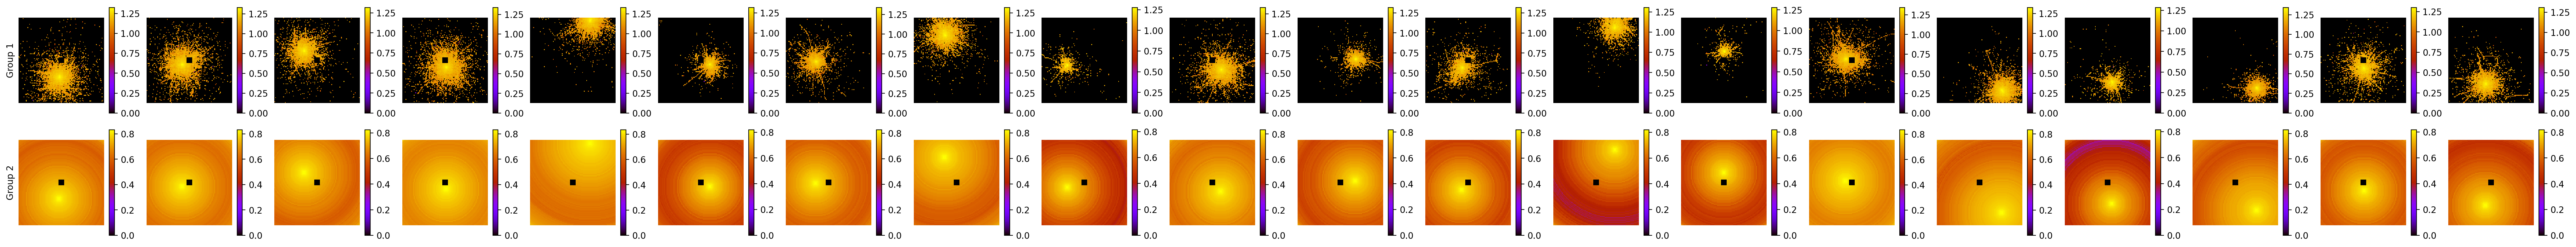

In [41]:

plot_responses_rows([
    characterisitc_transform.transform(train_responses.squeeze()[:20]),
    train_approxes.squeeze()[:20],
    # all_data['responses'][:10],
    # characterisitc_transform.inverse_transform(approx.squeeze().cpu().numpy()[:10]),
    # approx.squeeze().cpu().numpy()[:10],
])

In [4]:

from pathlib import Path
approx_checkpoints_dir = Path(f'/home/xsalonx/studia/inf.informaty-zlozonych-systemow/focal/trainings/approx/{approx_name}/checkpoints')
from focal.utils.train import get_last_epoch
from focal.models.approx.models.model3 import ParticleShowerNet as Model3
from focal.models.approx.utils import load_approx_model

device = 'cuda'

margs = { 'latent_dim': 16 }
approx_model = Model3(**margs).to(device)
apporx_last_epoch = get_last_epoch(approx_checkpoints_dir)
load_approx_model(approx_checkpoints_dir, approx_model, apporx_last_epoch)
print(f"Loaded from {apporx_last_epoch}")
for p in approx_model.parameters():
    p.requires_grad_(False)

/home/xsalonx/miniconda3/envs/torch1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded from 300


In [5]:

sample_particles, sample_responses, _, sample_centroids = data_scope['samples']
sample_particles = torch.Tensor(sample_particles).to(device)
sample_responses = sample_responses.transpose(0, 2, 3, 1)
sample_centroids = torch.Tensor(sample_centroids).to(device)
characterisitc_transform = data_scope['scalers'][2]
particles_transform = data_scope['scalers'][0]

def approx_pipeline(cond, centroids):
    with torch.no_grad():
        z = torch.randn(cond.size(0), 16, device=device)
        approx_responses = characterisitc_transform.transform(np.stack([
            get_image_from_characteristics(centroid, characterisitc_transform.inverse_transform(characteristic))
            for centroid, characteristic
            in tqdm(zip(centroids, approx_model(z, cond.squeeze(1)).squeeze(1).cpu().numpy()))
        ])[:, None])

    approx_responses = torch.Tensor(approx_responses).to(device)
    return approx_responses

In [6]:
from utilss.std.data_io import read_focal_data, save_focal_data

In [7]:
all_data = read_focal_data(path=data_dir)

In [8]:
approx = approx_pipeline(
    torch.Tensor(particles_transform.transform(all_data['particles'])).to(device),
    torch.Tensor(all_data['centroids']).to(device)
)

18346it [00:23, 797.60it/s]


In [9]:
save_focal_data(data_dir, data_dict={ f'approx/{approx_name}/approx': approx.squeeze().cpu().numpy() })

Saved approx/13lapx110-3-16-512-2.8e-3/approx


In [10]:
from utilss.plot import plot_responses_rows

(<Figure size 4200x800 with 40 Axes>,
 array([[<Axes: ylabel='Group 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Group 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

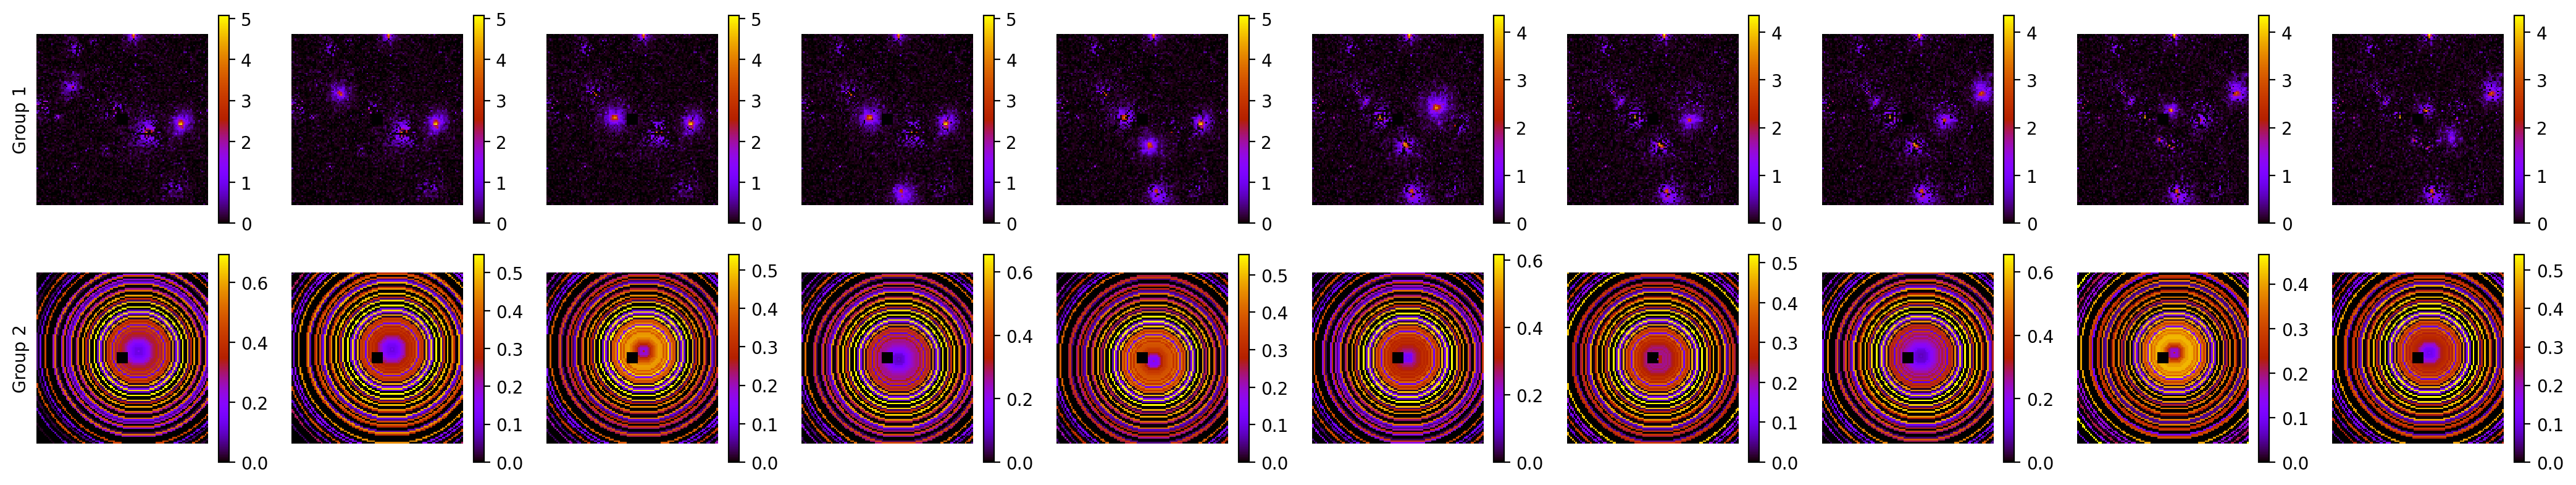

In [11]:
plot_responses_rows([
    characterisitc_transform.transform(all_data['responses'][:10]),
    # all_data['responses'][:10],
    # characterisitc_transform.inverse_transform(approx.squeeze().cpu().numpy()[:10]),
    approx.squeeze().cpu().numpy()[:10],
])